# 4f Edge Detection — Learning the Vortex Phase Filter

We optimise a **phase-only** filter at the Fourier plane of a 4f system to
perform edge detection.  The filter is trained end-to-end over a dataset of
random binary scenes using gradient descent, with no prior knowledge of the
analytical solution.

The optimiser should independently discover the **spiral (vortex) phase
filter** $\phi(x, y) = \arg(x + iy)$, the well-known phase-only Fourier
filter for isotropic edge enhancement.

> **Prerequisites:** the [4f correlator notebook](4f_correlator_example.ipynb)
> covers the sampling-matched focal length and 4f geometry used here.

## 1  Imports

In [6]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from fouriax.optics import (
    ComplexMask,
    Field,
    Grid,
    IntensitySensor,
    OpticalModule,
    Spectrum,
    ThinLens,
)
from fouriax.optics.propagation import ASMPropagator

%matplotlib inline

## 2  Why a Phase-Only Filter Can Detect Edges

A standard 4f system with no filter ($H = 1$) images the input with a
spatial inversion.  Placing a **spiral phase mask**

$$
H(x, y) = e^{\,i\,\text{atan2}(y,\,x)}
$$

at the Fourier plane performs a **radial Hilbert transform**, which is
equivalent to isotropic edge detection.  Intuitively, the vortex phase
introduces a $\pi$ phase shift between diametrically opposite spatial
frequencies.  At any edge in the scene these opposite frequencies
interfere constructively, while in flat regions they cancel.

Since the filter is phase-only, it preserves total optical power — all
photons reach the output plane, they are simply redistributed from flat
regions to edges.

## 3  Simulation Parameters

In [7]:
WAVELENGTH_UM = 0.532
N_MEDIUM      = 1.0
GRID_N        = 128
GRID_DX_UM    = 2.0

grid     = Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = Spectrum.from_scalar(WAVELENGTH_UM)

f_um = N_MEDIUM * grid.nx * grid.dx_um**2 / WAVELENGTH_UM
paraxial_fom = (WAVELENGTH_UM / (2 * N_MEDIUM * GRID_DX_UM)) ** 2

print(f"Sampling-matched focal length: f = {f_um:.1f} µm")
print(f"Paraxial figure of merit (r_max/f)² = {paraxial_fom:.4f}  "
      f"({'good' if paraxial_fom < 0.05 else 'marginal'})")

Sampling-matched focal length: f = 962.4 µm
Paraxial figure of merit (r_max/f)² = 0.0177  (good)


## 4  Training Data — Random Binary Scenes

Each training scene is generated by:

1. Drawing white noise on the simulation grid.
2. Low-pass filtering in $k$-space to produce smooth blobs.
3. Thresholding at zero to obtain a binary scene.

The smoothing scale controls feature size; larger values yield bigger
blobs with fewer, longer edges.  The corresponding edge targets are
computed via central finite differences (a discrete gradient magnitude).

In [8]:
def random_scene(key, grid):
    noise = jax.random.normal(key, grid.shape)
    k = jnp.fft.fftn(noise, axes=(-2, -1))
    fx, fy = grid.frequency_grid()
    sigma_freq = 1.0 / (32.0 * grid.dx_um)
    lpf = jnp.exp(-(fx**2 + fy**2) / (2 * sigma_freq**2))
    smooth = jnp.real(jnp.fft.ifftn(k * lpf, axes=(-2, -1)))
    return (smooth > 0).astype(jnp.float32)


def edge_target(scene):
    padded = jnp.pad(scene, 1, mode="edge")
    gx = padded[1:-1, 2:] - padded[1:-1, :-2]
    gy = padded[2:, 1:-1] - padded[:-2, 1:-1]
    mag = jnp.sqrt(gx**2 + gy**2)
    return mag / jnp.maximum(jnp.max(mag), 1e-12)

In [9]:
N_TRAIN = 1000
N_TEST  = 100

key = jax.random.PRNGKey(42)
key, *train_keys = jax.random.split(key, N_TRAIN + 1)
train_scenes  = jnp.stack([random_scene(k, grid) for k in train_keys])
train_targets = jnp.stack([edge_target(s) for s in train_scenes])

key, *test_keys = jax.random.split(key, N_TEST + 1)
test_scenes  = jnp.stack([random_scene(k, grid) for k in test_keys])
test_targets = jnp.stack([edge_target(s) for s in test_scenes])

print(f"Training set: {N_TRAIN} scenes, Test set: {N_TEST} scenes")

Training set: 1000 scenes, Test set: 100 scenes


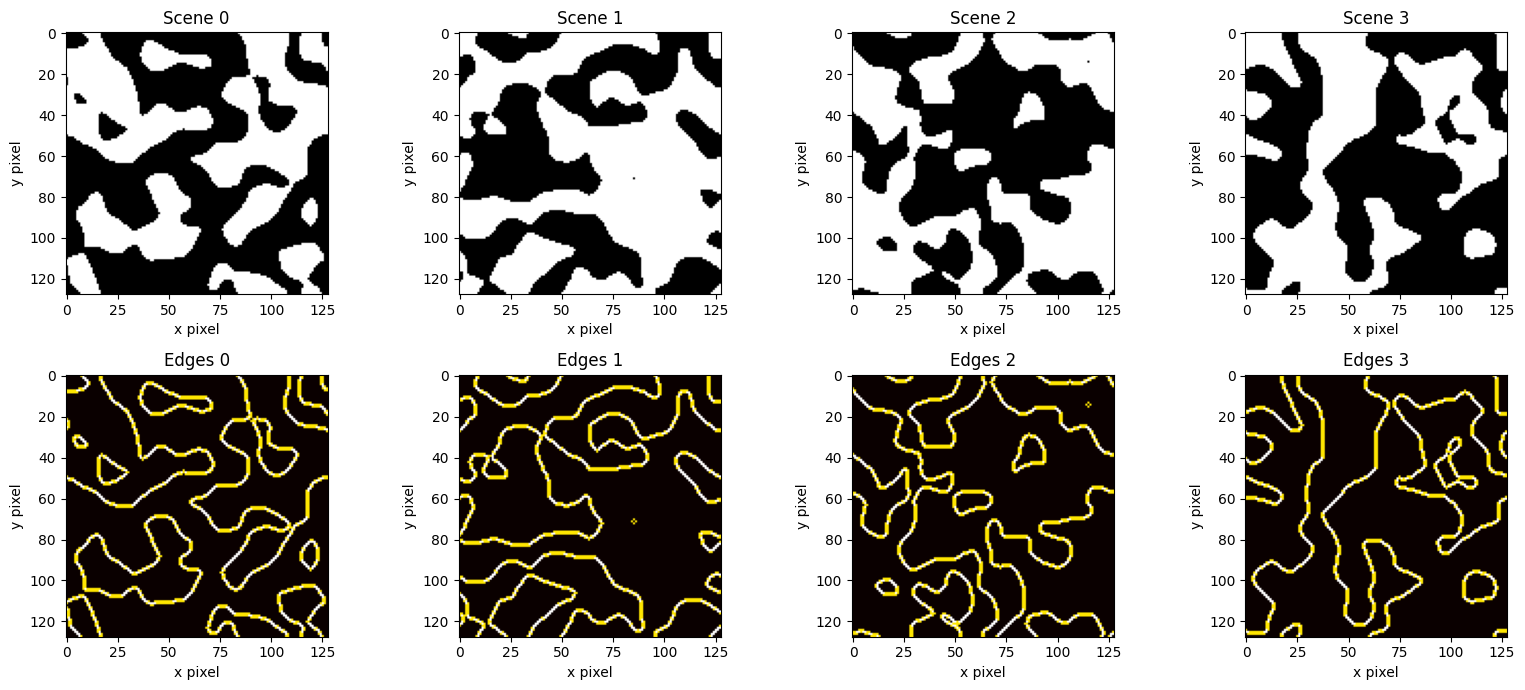

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col in range(4):
    axes[0, col].imshow(np.asarray(train_scenes[col]), cmap="gray")
    axes[0, col].set_title(f"Scene {col}")
    axes[1, col].imshow(np.asarray(train_targets[col]), cmap="hot")
    axes[1, col].set_title(f"Edges {col}")
for ax in axes.flat:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.tight_layout()
plt.show()

## 5  Build the 4f System

The system follows the same geometry as the correlator notebook:

$$
\text{input}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_1
\;\xrightarrow{\text{prop}(f)}\;
\underbrace{e^{\,i\,\phi(x,y)}}_{\text{phase filter}}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_2
\;\xrightarrow{\text{prop}(f)}\;
\text{output}
$$

The phase $\phi$ is the **only trainable parameter**.  We parameterise it
as $\phi = 2\pi\,\sigma(\theta)$ where $\sigma$ is the sigmoid function
and $\theta$ is an unconstrained array optimised by Adam.

In [11]:
prop = ASMPropagator(
    distance_um=f_um, use_sampling_planner=False, warn_on_regime_mismatch=False,
)
lens = ThinLens(focal_length_um=f_um)


def apply_4f(phase, scene):
    """Run a scene through the 4f system with the given Fourier-plane phase."""
    field_in = Field.plane_wave(grid=grid, spectrum=spectrum).apply_amplitude(
        scene[None, :, :],
    )
    module = OpticalModule(
        layers=(
            prop, lens, prop,
            ComplexMask(phase_map_rad=phase),
            prop, lens, prop,
        ),
        sensor=IntensitySensor(sum_wavelengths=True),
    )
    return module.measure(field_in)[::-1, ::-1]  # undo double-FT inversion

## 6  Loss Function and Optimisation

The loss is the mean squared error between the normalised 4f output
intensity and the target edge map.  Each gradient step uses one training
scene (SGD with batch size 1), cycling through the dataset.  Test loss
is evaluated every 50 steps on a held-out subset.

In [12]:
def loss_fn(raw_phase, scene, target):
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    out = apply_4f(phase, scene)
    out_n = out / jnp.maximum(jnp.max(out), 1e-12)
    return jnp.mean((out_n - target) ** 2)


@jax.jit
def eval_loss(raw_phase, scene, target):
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    out = apply_4f(phase, scene)
    out_n = out / jnp.maximum(jnp.max(out), 1e-12)
    return jnp.mean((out_n - target) ** 2)

In [13]:
STEPS = 1000
LR    = 1e-1

key, init_key = jax.random.split(key)
raw_phase = 0.1 * jax.random.normal(init_key, (grid.ny, grid.nx))
optimizer = optax.adam(LR)
opt_state = optimizer.init(raw_phase)
vg = jax.jit(jax.value_and_grad(loss_fn))

n_test_eval = min(10, N_TEST)
train_history = []
test_history  = []

for step in range(STEPS):
    idx = step % N_TRAIN
    loss, grad = vg(raw_phase, train_scenes[idx], train_targets[idx])
    updates, opt_state = optimizer.update(grad, opt_state, raw_phase)
    raw_phase = optax.apply_updates(raw_phase, updates)
    train_history.append(float(loss))
    if step % 50 == 0 or step == STEPS - 1:
        test_losses = [float(eval_loss(raw_phase, test_scenes[i], test_targets[i]))
                       for i in range(n_test_eval)]
        test_loss = float(np.mean(test_losses))
        test_history.append((step, test_loss))
        print(f"step={step:03d}  train={float(loss):.6f}  test={test_loss:.6f}")

final_phase = np.asarray(2.0 * jnp.pi * jax.nn.sigmoid(raw_phase))

step=000  train=0.106305  test=0.102254
step=050  train=0.088205  test=0.084194
step=100  train=0.081138  test=0.083224
step=150  train=0.083916  test=0.082322
step=200  train=0.073391  test=0.082167
step=250  train=0.077675  test=0.081950
step=300  train=0.085377  test=0.081569
step=350  train=0.079027  test=0.080407
step=400  train=0.077740  test=0.080007
step=450  train=0.083882  test=0.078679
step=500  train=0.080483  test=0.079511
step=550  train=0.079452  test=0.078681
step=600  train=0.077856  test=0.077586
step=650  train=0.078657  test=0.077147
step=700  train=0.081129  test=0.077701
step=750  train=0.079114  test=0.077430
step=800  train=0.075240  test=0.076604
step=850  train=0.074098  test=0.077942
step=900  train=0.074740  test=0.076852
step=950  train=0.080592  test=0.077521
step=999  train=0.076539  test=0.078451


## 7  Training and Test Loss

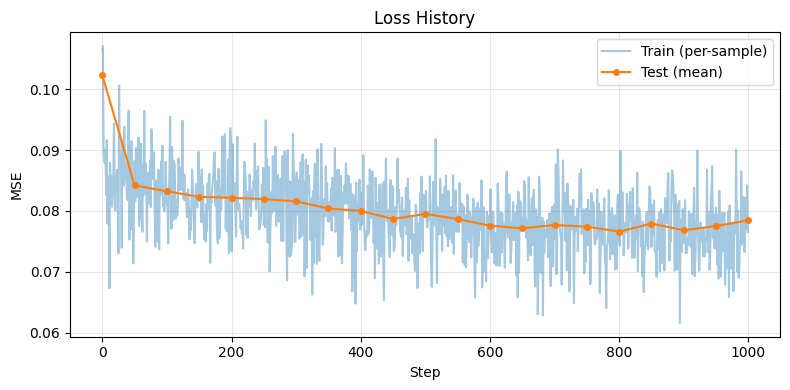

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_history, alpha=0.4, label="Train (per-sample)")
test_steps, test_vals = zip(*test_history)
ax.plot(test_steps, test_vals, "o-", markersize=4, label="Test (mean)")
ax.set_xlabel("Step")
ax.set_ylabel("MSE")
ax.set_title("Loss History")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8  Evaluate on a Held-Out Geometric Test Scene

To test generalisation, we evaluate the optimised filter on a hand-crafted
geometric scene (rectangles + disk) that was never seen during training.

Pearson correlation on geometric test scene: ρ = 0.6561


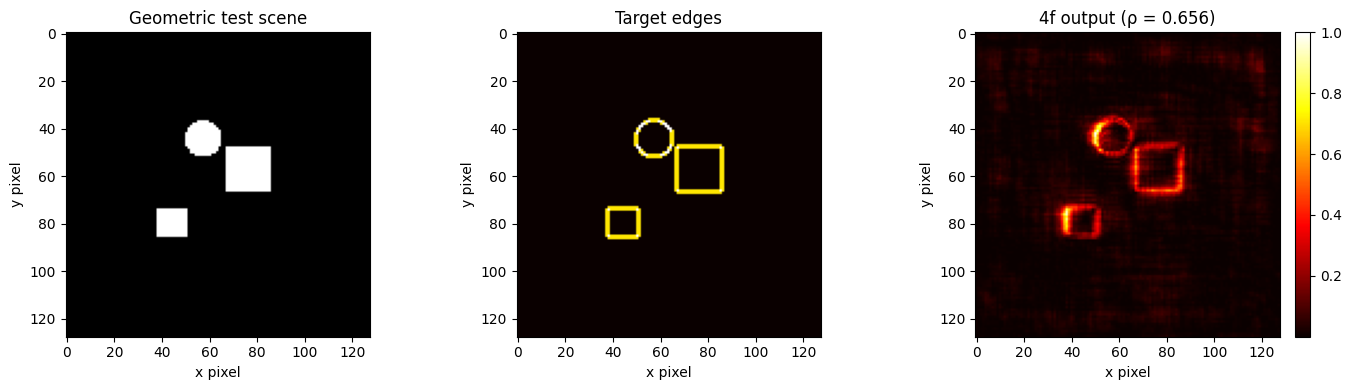

In [15]:
x, y = grid.spatial_grid()
half = grid.nx * grid.dx_um / 2.0
geo_scene = jnp.zeros(grid.shape, dtype=jnp.float32)
geo_scene = geo_scene + ((jnp.abs(x - 0.2*half) < 0.15*half)
                          & (jnp.abs(y + 0.1*half) < 0.15*half)).astype(jnp.float32)
geo_scene = geo_scene + ((jnp.abs(x + 0.3*half) < 0.1*half)
                          & (jnp.abs(y - 0.25*half) < 0.1*half)).astype(jnp.float32)
r = jnp.sqrt((x + 0.1*half)**2 + (y + 0.3*half)**2)
geo_scene = geo_scene + (r < 0.12*half).astype(jnp.float32)
geo_scene = jnp.clip(geo_scene, 0.0, 1.0)

geo_target = edge_target(geo_scene)
geo_out = np.asarray(apply_4f(final_phase, geo_scene))
geo_out_n = geo_out / np.max(geo_out)
cc = float(np.corrcoef(geo_out_n.ravel(), np.asarray(geo_target).ravel())[0, 1])
print(f"Pearson correlation on geometric test scene: ρ = {cc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(np.asarray(geo_scene), cmap="gray")
axes[0].set_title("Geometric test scene")
axes[1].imshow(np.asarray(geo_target), cmap="hot")
axes[1].set_title("Target edges")
im = axes[2].imshow(geo_out_n, cmap="hot")
axes[2].set_title(f"4f output (ρ = {cc:.3f})")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.tight_layout()
plt.show()

## 9  Comparison with the Analytical Spiral Phase

The known optimal phase-only Fourier filter for isotropic edge detection
is the vortex (spiral) phase:

$$
\phi_{\text{spiral}}(x, y) = \text{atan2}(y, x) + \pi
$$

where $(x, y)$ are centred coordinates in the Fourier plane (DC at the
optical axis).  We compare the optimised phase to this analytical
solution visually.

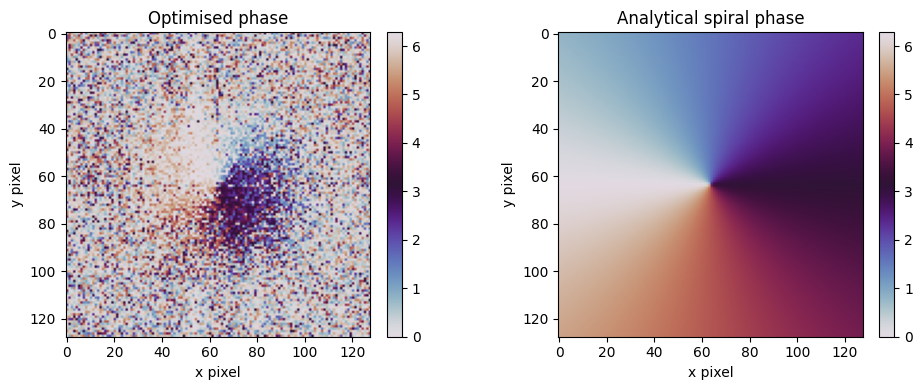

In [16]:
spiral_phase = np.asarray(jnp.arctan2(y, x) + jnp.pi)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(final_phase, cmap="twilight", vmin=0, vmax=2*np.pi)
axes[0].set_title("Optimised phase")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(spiral_phase, cmap="twilight", vmin=0, vmax=2*np.pi)
axes[1].set_title("Analytical spiral phase")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.tight_layout()
plt.show()